# Задание 2 по биоинформатике




## Часть 1. Множественное выравнивание

Для анализа были использованы гомологичные белки **cytochrome c** у 4 видов:

- **Homo sapiens**
- **Mus musculus**
- **Rattus norvegicus**
- **Gallus gallus**

Последовательности были скачаны в формате FASTA из базы UniProt, затем объединены в один общий FASTA-файл и использованы для множественного выравнивания.


### Скрин множественного выравнивания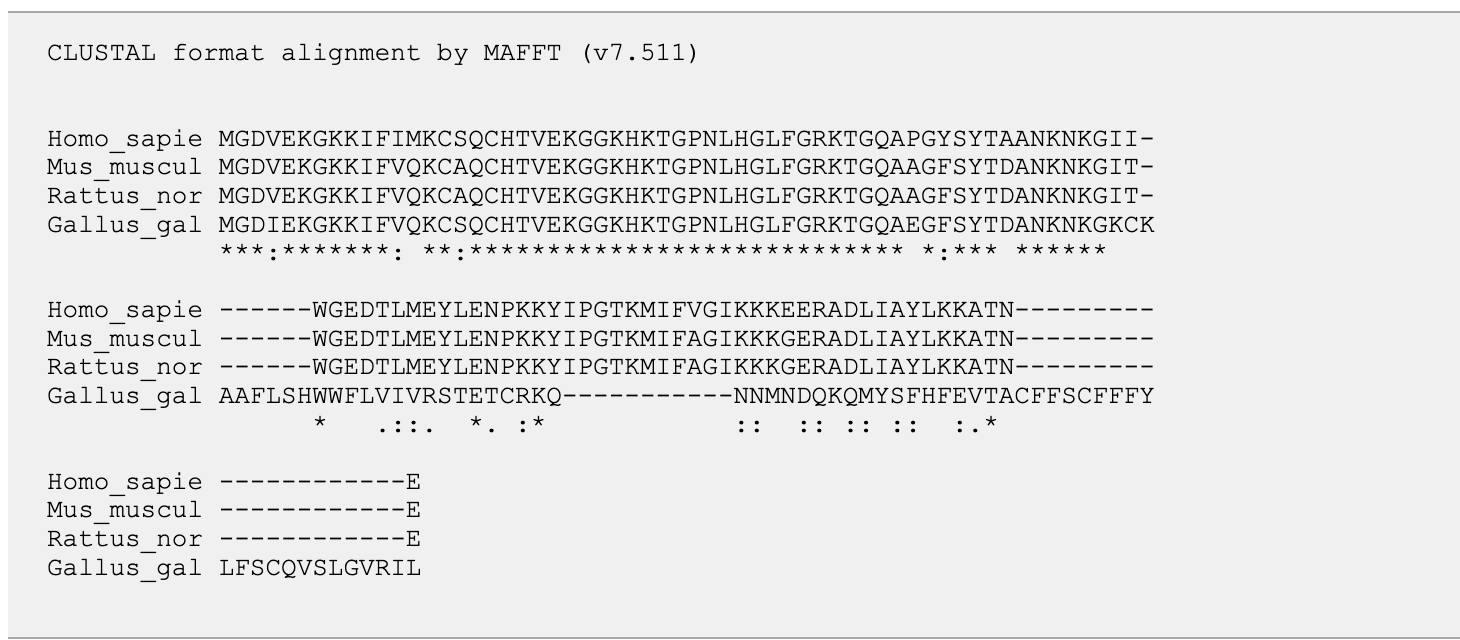

### Филогенетическое дерево
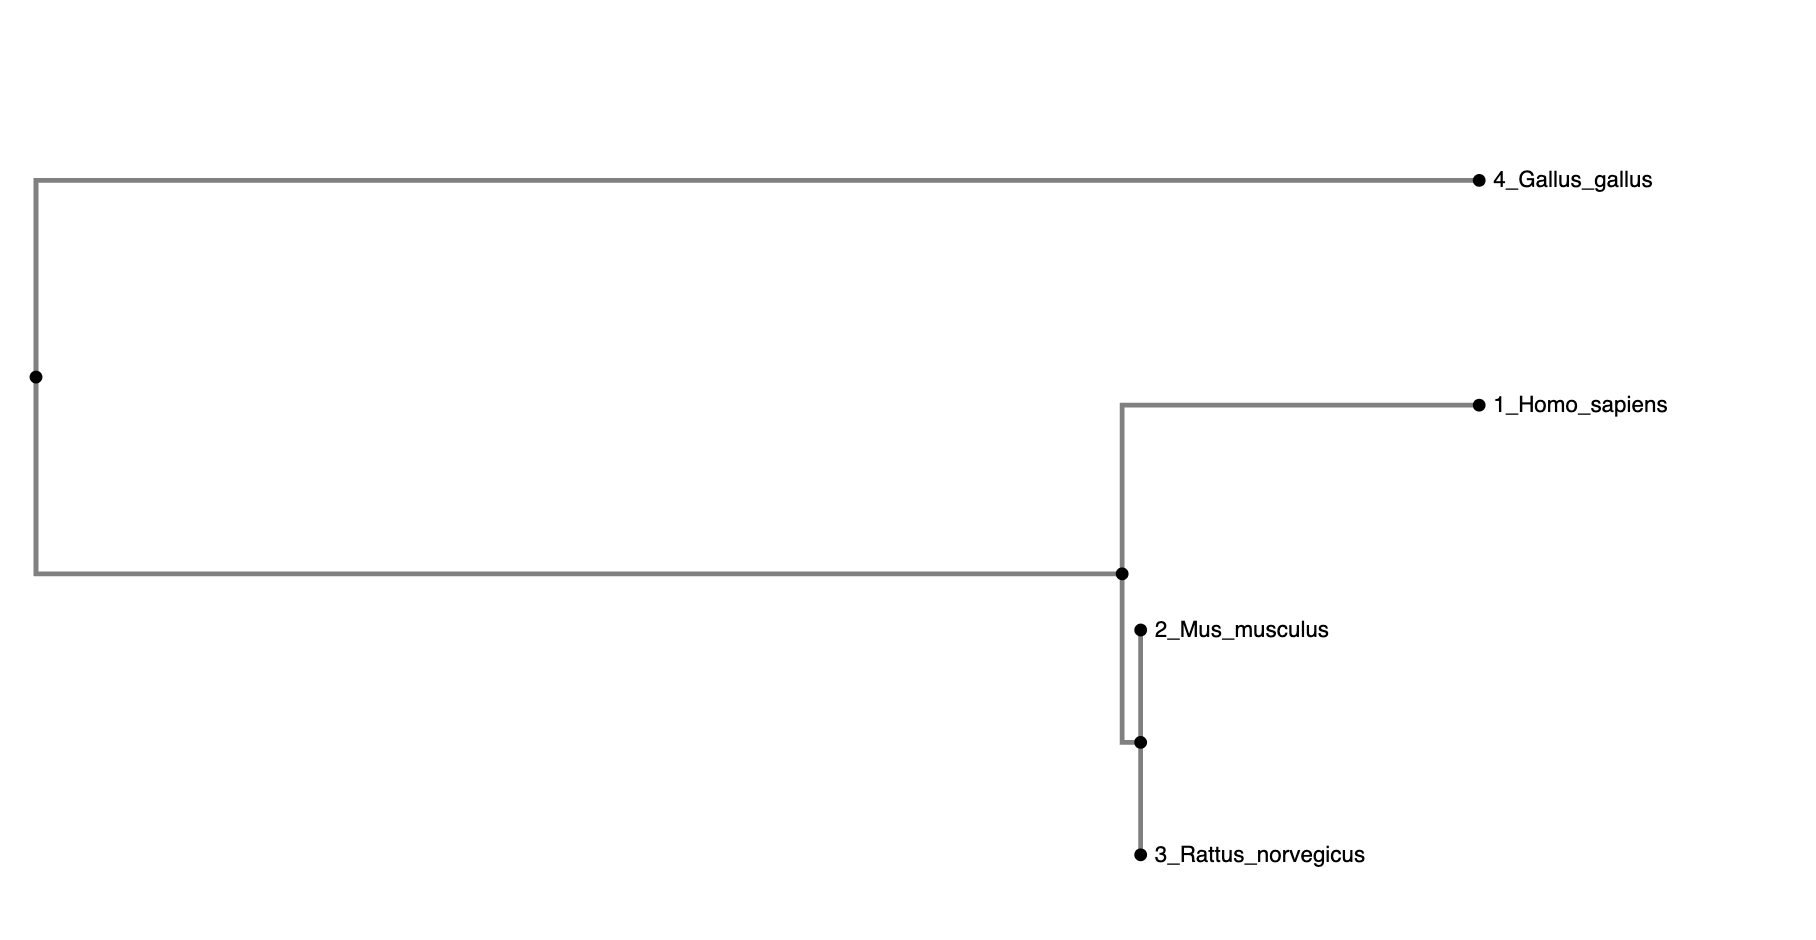


## Часть 2. MEGA и коронавирус




### 2.1. Выравнивание и дерево для исходного набора последовательностей

Для файла `S_prot_sequences.fasta` было выполнено множественное выравнивание, после чего на его основе построено филогенетическое дерево.

#### Филогенетическое дерево
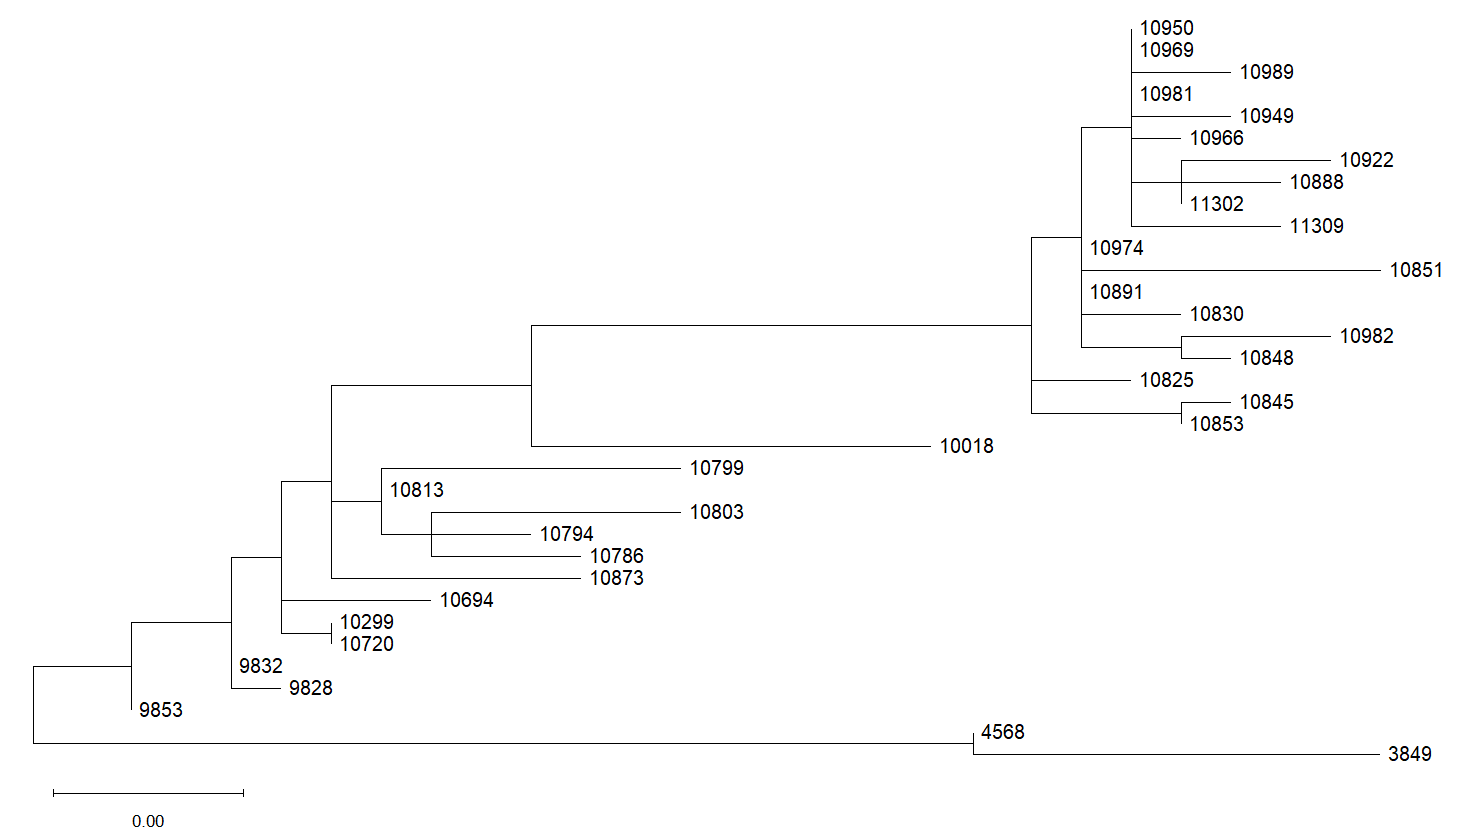


#### Вывод по пункту 2.1

По построенному дереву видно, что большая часть образцов формирует компактную основную группу. При этом образцы **4568** и **3849** расположены заметно дальше от основного кластера, что может указывать на их большую генетическую удалённость.


### 2.2. Добавление трёх последовательностей из других штаммов

К исходному набору были добавлены три дополнительные последовательности S-белка SARS-CoV-2. В качестве внешних последовательностей использовались образцы человека с длиной около 1270 аминокислот и географической привязкой к Африке.


#### Филогенетическое дерево для расширенного набора
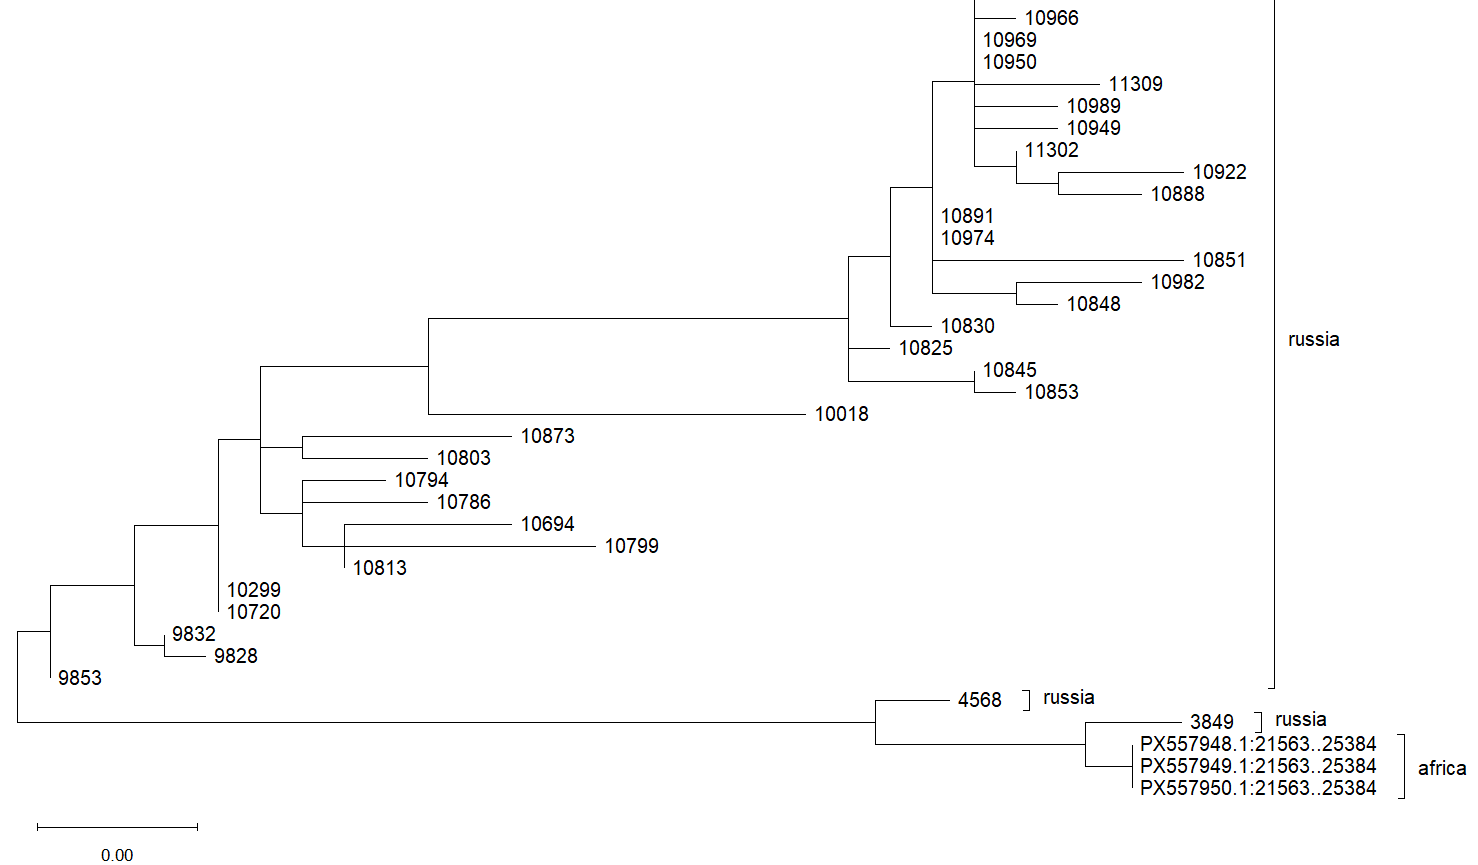


#### Вывод по пункту 2.2

После добавления трёх внешних последовательностей стало видно, что они образуют собственную группу и располагаются отдельно от основного массива образцов из Росии. При этом часть исходных образцов, в частности **4568** и **3849**, оказывается ближе к этой группе, чем остальные последовательности. У всех вирусов был общий исходник.


## Часть 3. BLAST


### 3.1. Анализ неизвестного белка

Для последовательности

```text
EGMQCSCGIDYYTPHEETNNESFVIYMFVVHFIIPLIVIFFCYGQLVFTVKEAAAQQQES
```

был выполнен поиск по базе **nr** с помощью BLAST для определения наиболее вероятного белка.



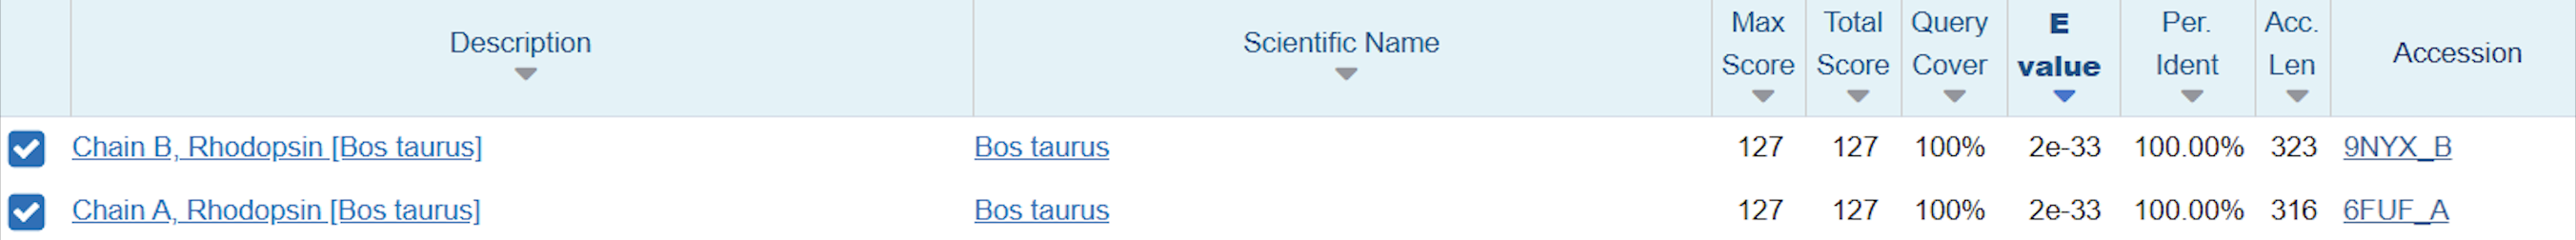



По результатам  наиболее вероятно, что данная последовательность соответствует **родопсину**. Для поиска ортолога у человека был выбран **blastp**, поскольку исходная последовательность является белковой, а сравнение белок-белок удобнее для поиска близких гомологов и интерпретации результата. В качестве базы использовалась `refseq_protein`.

Наиболее похожим человеческим белком оказался **rhodopsin [Homo sapiens]**.

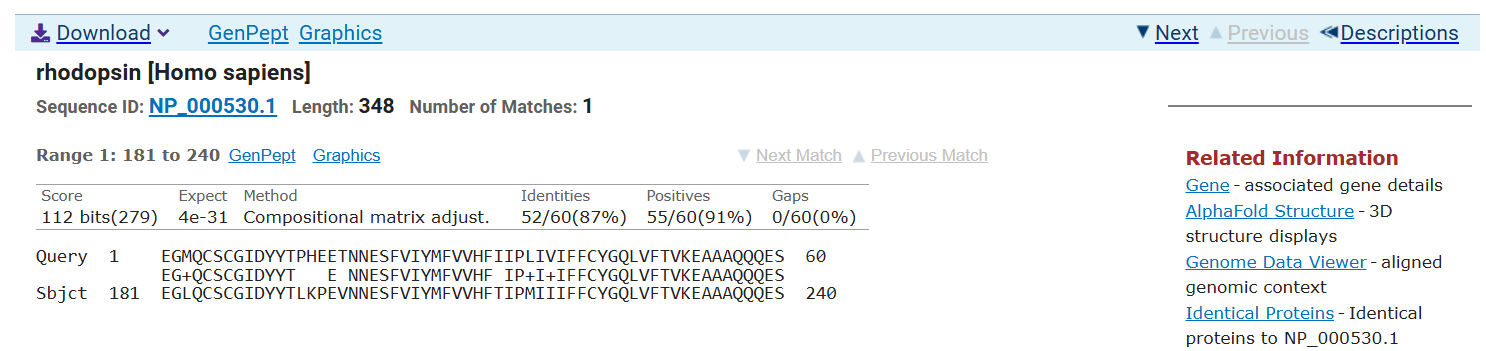


### Нарушения зрения 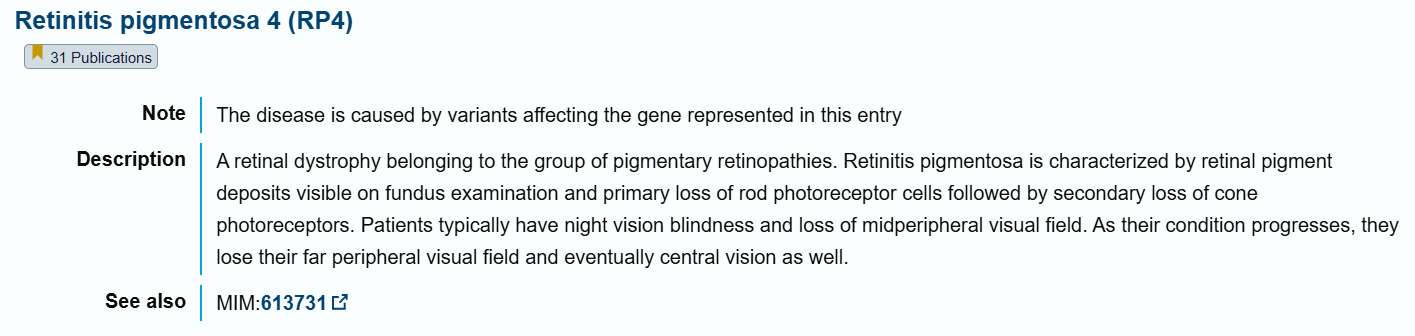

#### Вывод по пункту 3.1

BLAST-анализ показал, что неизвестная последовательность соответствует родопсину. У человека наиболее близким гомологом также является родопсин, а мутации в этом белке связаны с наследственными нарушениями зрения, затрагивающими функцию сетчатки.


### 3.2. Поиск кандидатов на люциферазу в транскриптоме

Для поиска кандидатов на белковую последовательность люциферазы использовались:
- белковая последовательность люциферазы **Luciola cruciata**;
- транскриптом **Photinus pyralis**.




#### Ход работы

1. В качестве входных данных использовали последовательность люциферазы `Luciola cruciata` и транскриптом `Photinus pyralis`.
2. Для поиска открытых рамок считывания и перевода транскриптов в аминокислотные последовательности была использована команда:

```bash
TransDecoder.LongOrfs -t ppyralis_transcriptome.fasta
```

3. На основе полученных белковых последовательностей была создана BLAST-база:

```bash
makeblastdb -in ppyralis_transcriptome.fasta.transdecoder_dir/longest_orfs.pep -dbtype prot -out ppyralis_blastdb
```

4. Затем был выполнен поиск похожих белков с помощью `blastp`:

```bash
blastp -query lcruciata_luc.fasta -db ppyralis_blastdb -outfmt 6 -max_target_seqs 10 -num_threads 2 -out blast_results.txt
```

5. После получения десяти лучших хитов были извлечены их идентификаторы и сохранены соответствующие последовательности:

```bash
cut -f2 blast_results.txt > top10_ids.txt
seqtk subseq ppyralis_transcriptome.fasta.transdecoder_dir/longest_orfs.pep top10_ids.txt > top10_candidates.fasta
```
